In [1]:
# %% 1. Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations --quiet
import os, random, warnings, cv2, math, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from albumentations import Compose, Resize, ShiftScaleRotate, RandomBrightnessContrast, GaussianBlur, CoarseDropout, Lambda
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Mounted at /content/drive
Device: cuda


In [2]:
# %% 2. Hyper-params & paths
SHAPE_SOURCES = {
    "shape7":  ("/content/shape7_labels_all.csv", "/content/drive/MyDrive/shapes/shape7"),
    "shape9":  ("/content/shape9_scores.csv",     "/content/drive/MyDrive/shapes/shape9"),
    "shape14": ("/content/shape14_scores.xlsx",   "/content/drive/MyDrive/shapes/shape14"),
    "shape18": ("/content/shape18_scores.csv",    "/content/drive/MyDrive/shapes/shape18"),
}

IMG_SIZE   = 128
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 3e-4
PATIENCE   = 10
TOL        = 1          # ±1 tolerance for accuracy


In [3]:
# %% 3. Smart auto-crop
def smart_center_crop(img: np.ndarray, thr=20):
    ys, xs = np.where(img > thr)
    if xs.size == 0: return img
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    side = max(x1 - x0, y1 - y0) + 2
    cx, cy = (x0 + x1)//2, (y0 + y1)//2
    half = side//2
    x0, x1, y0, y1 = cx-half, cx+half, cy-half, cy+half
    pad_x0, pad_y0 = max(-x0,0), max(-y0,0)
    pad_x1, pad_y1 = max(x1-img.shape[1]+1,0), max(y1-img.shape[0]+1,0)
    if pad_x0+pad_x1+pad_y0+pad_y1:
        img = np.pad(img, ((pad_y0,pad_y1),(pad_x0,pad_x1)), constant_values=0)
        y0+=pad_y0; y1+=pad_y0; x0+=pad_x0; x1+=pad_x0
    return img[y0:y1+1, x0:x1+1]

class SmartCrop:
    def __init__(self, thr=20): self.thr=thr
    def __call__(self, img, **kw): return smart_center_crop(img, self.thr)


In [4]:
from albumentations import Normalize

train_tf = Compose([
    Lambda(image=SmartCrop(20)),
    Resize(IMG_SIZE, IMG_SIZE),
    ShiftScaleRotate(0.05, 0.05, 10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    RandomBrightnessContrast(0.2, 0.2, p=0.5),
    GaussianBlur(blur_limit=3, p=0.3),
    CoarseDropout(max_holes=4, max_height=16, max_width=16,
                  min_holes=1, min_height=8, min_width=8,
                  fill_value=0, p=0.3),
    Normalize(mean=[0.485], std=[0.229]),  # <-- NEW normalization for grayscale
    ToTensorV2()
])
val_tf = Compose([
    Lambda(image=SmartCrop(20)),
    Resize(IMG_SIZE, IMG_SIZE),
    Normalize(mean=[0.485], std=[0.229]),  # <-- NEW normalization for grayscale
    ToTensorV2()
])

class ShapeDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((200, 200), np.uint8)
        img = self.tf(image=img)["image"].float()
        return img, torch.tensor(row.label, dtype=torch.float32)


In [5]:


# %% 5. Model
class ResNet18Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features,1)
    def forward(self,x): return self.backbone(x).squeeze(1)


In [6]:

# %% 6. Metrics
mae = lambda p,t: torch.mean(torch.abs(p-t)).item()
def acc_std(p,t): return (torch.round(p).int()==t.int()).float().mean().item()*100
def acc_tol(p,t, tol=TOL): return (torch.abs(torch.round(p)-t)<=tol).float().mean().item()*100


In [7]:
# %% 7. Train one fold
from tqdm.notebook import tqdm
from torch.utils.data import WeightedRandomSampler, DataLoader

def run_fold(train_idx, val_idx, full_df, fold_id):
    # --- split data
    train_df, val_df = full_df.iloc[train_idx], full_df.iloc[val_idx]

    # --- weighted sampler to offset label imbalance
    counts  = train_df.label.value_counts().sort_index().values
    weights = 1.0 / (counts + 1e-6)
    sample_w = train_df.label.apply(lambda l: weights[int(l) - 1]).values
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    # --- loaders
    train_loader = DataLoader(
        ShapeDataset(train_df, train_tf),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        ShapeDataset(val_df, val_tf),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --- model, optimiser, scheduler
    model = ResNet18Reg().to(device)
    for n, p in model.backbone.named_parameters():
        p.requires_grad = n.startswith("layer4") or n.startswith("fc")
    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    sch = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=3, min_lr=1e-6, verbose=False
    )
    loss_fn = nn.MSELoss()  # L2 loss

    # --- training loop
    best_mae, patience = 1e9, 0
    train_losses, val_maes = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in tqdm(train_loader,
                         desc=f"Fold {fold_id} | Epoch {epoch}/{EPOCHS}",
                         leave=False):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            out  = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)

        epoch_loss = running / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- validation
        model.eval()
        preds, targs = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                preds.append(model(x).cpu())
                targs.append(y.cpu())
        preds = torch.cat(preds)
        targs = torch.cat(targs)
        v_mae = mae(preds, targs)
        val_maes.append(v_mae)
        sch.step(v_mae)

        print(f"Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f} "
              f"| Val MAE: {v_mae:.4f} | Patience: {patience}")

        # --- early stopping
        if v_mae < best_mae - 1e-3:
            best_mae, patience = v_mae, 0
            torch.save(model.state_dict(), f"/content/best_fold{fold_id}.pth")
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    # --- reload best weights
    model.load_state_dict(torch.load(f"/content/best_fold{fold_id}.pth",
                                     map_location=device))
    model.eval()
    preds, targs = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            preds.append(model(x).cpu())
            targs.append(y.cpu())
    preds, targs = torch.cat(preds), torch.cat(targs)

    # --- store logs for later visualisation
    model._train_logs = {
        "train_loss": train_losses,
        "val_mae":     val_maes,
        "val_targets": targs,
        "val_preds":   preds
    }

    return mae(preds, targs), acc_std(preds, targs), acc_tol(preds, targs), model


In [8]:
# %% 8. 5-fold CV with held-out test set (merge four shape sets)
from sklearn.model_selection import train_test_split

frames = []
for shape_name, (score_file, img_dir) in SHAPE_SOURCES.items():
    if score_file.lower().endswith((".xls", ".xlsx")):
        df_shape = pd.read_excel(score_file)
    else:
        df_shape = pd.read_csv(score_file, encoding="utf-8")

    # absolute path to the PNG for each child_id
    df_shape["img_path"] = df_shape["child_id"].apply(
        lambda cid: os.path.join(img_dir, f"{cid}.png")
    )
    df_shape = df_shape[df_shape["img_path"].apply(os.path.exists)]
    frames.append(df_shape)

df = pd.concat(frames, ignore_index=True)
print("Total samples:", len(df))

# ===== NEW: Split off test set first =====
df_trainval, df_test = train_test_split(
    df, test_size=0.2, stratify=df.label, random_state=SEED
)
print(f"Train+Val: {len(df_trainval)} | Test: {len(df_test)}")

# ===== Run 5-fold CV on train+val only =====
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)

mae_list, std_list, tol_list = [], [], []
fold_models = []

for fold, (tr, va) in enumerate(skf.split(df_trainval, df_trainval.label), 1):
    m, s, t, model = run_fold(tr, va, df_trainval, fold)  # Note: using df_trainval
    mae_list.append(m); std_list.append(s); tol_list.append(t); fold_models.append(model)
    print(f"Fold{fold}: MAE {m:.3f} | ±0 {s:.1f}% | ±{TOL} {t:.1f}%")

print(f"\n5-fold avg MAE {np.mean(mae_list):.3f}±{np.std(mae_list):.3f}")
print(f"5-fold avg ±0 {np.mean(std_list):.1f}% | ±{TOL} {np.mean(tol_list):.1f}%")

best_model = fold_models[np.argmin(mae_list)]

Total samples: 3557
Train+Val: 2845 | Test: 712


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Fold 1 | Epoch 1/60:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 4.0900 | Val MAE: 1.1167 | Patience: 0


Fold 1 | Epoch 2/60:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 41 | Train Loss: 0.4970 | Val MAE: 0.7157 | Patience: 7


Fold 5 | Epoch 42/60:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 42 | Train Loss: 0.5139 | Val MAE: 0.7416 | Patience: 8


Fold 5 | Epoch 43/60:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 43 | Train Loss: 0.5305 | Val MAE: 0.6856 | Patience: 9
Fold5: MAE 0.676 | ±0 46.7% | ±1 91.2%

5-fold avg MAE 0.674±0.012
5-fold avg ±0 47.3% | ±1 90.7%


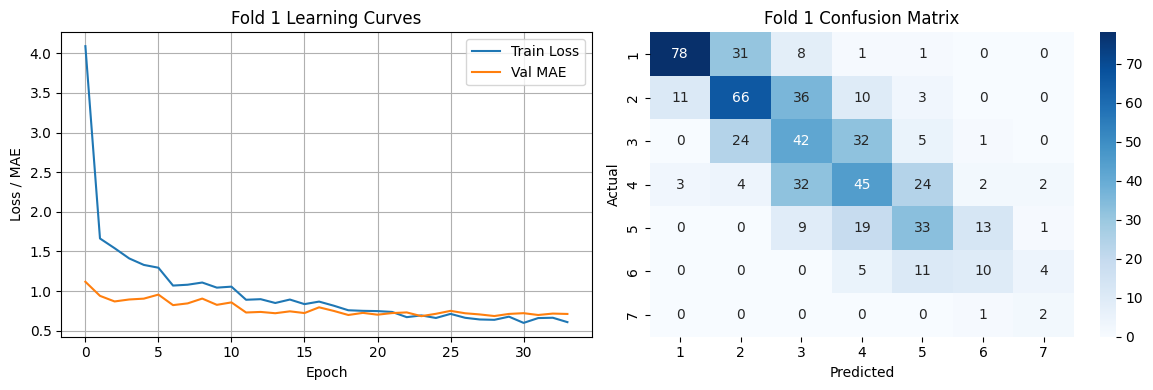

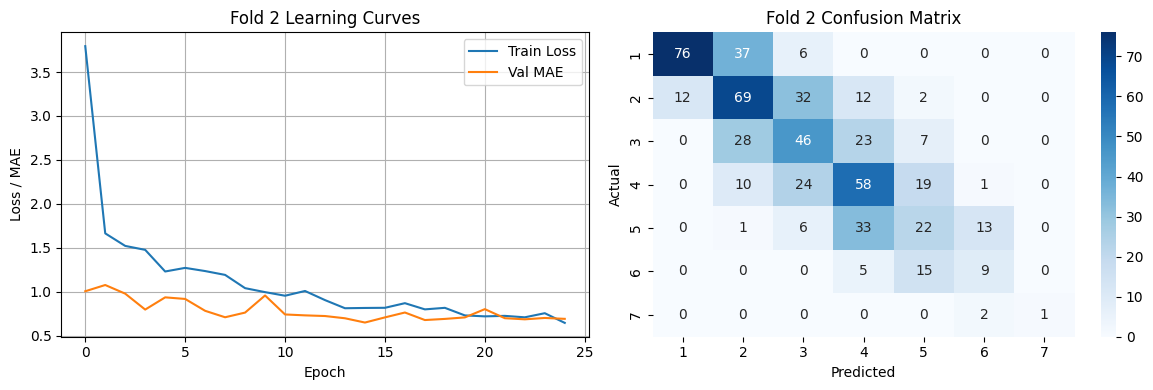

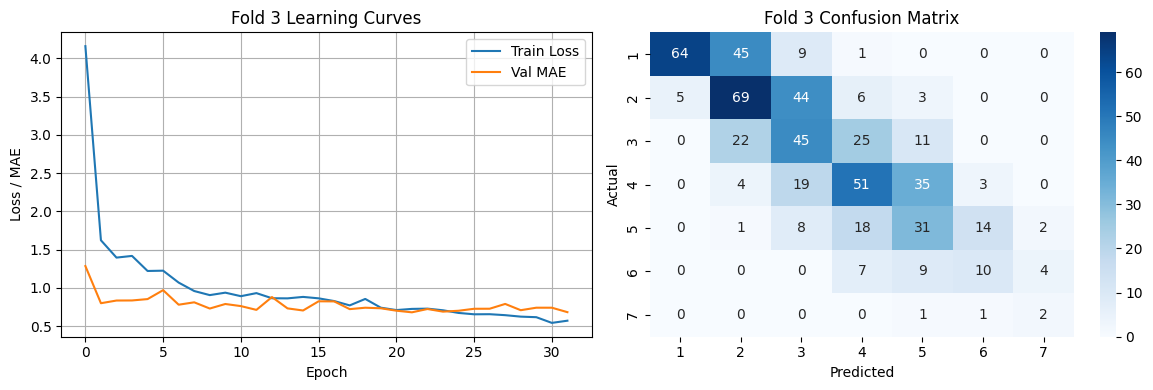

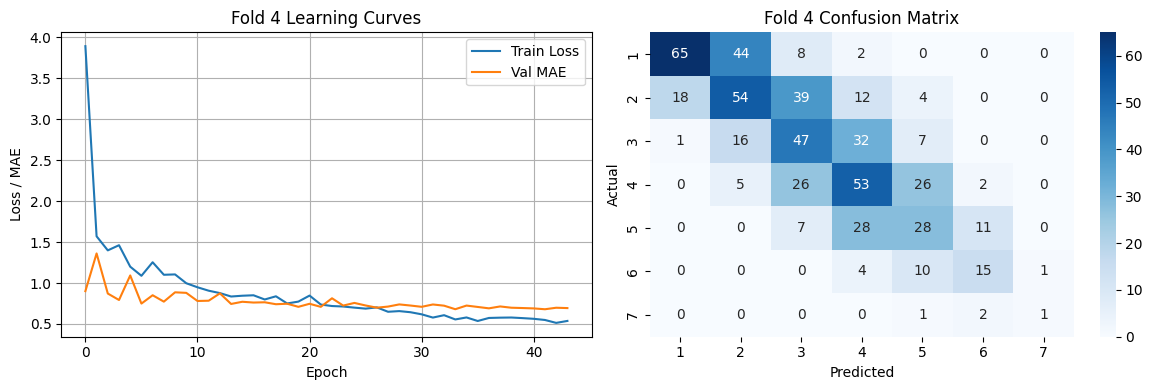

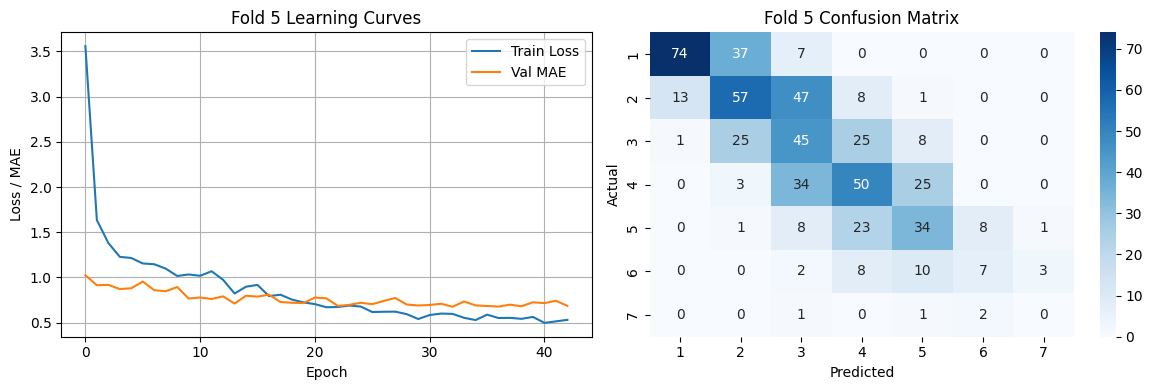

In [9]:
# %% 9. Analyze training: learning curves & confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_fold_analysis(model, fold_id):
    logs = model._train_logs
    train_loss, val_mae = logs['train_loss'], logs['val_mae']
    pv, tv = logs['val_preds'], logs['val_targets']

    # Plot learning curves
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_mae, label="Val MAE")
    plt.title(f"Fold {fold_id} Learning Curves")
    plt.xlabel("Epoch"); plt.ylabel("Loss / MAE")
    plt.legend(); plt.grid(True)

    # Confusion Matrix with ±1 tolerance
    pred_rounded = pv.numpy().round().clip(1,7).astype(int)
    true_labels  = tv.numpy().round().astype(int)
    cm = confusion_matrix(true_labels, pred_rounded, labels=[1,2,3,4,5,6,7])

    plt.subplot(1,2,2)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1,8), yticklabels=range(1,8))
    plt.title(f"Fold {fold_id} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Plot for each fold
for i, model in enumerate(fold_models, 1):
    plot_fold_analysis(model, i)

FINAL TEST SET EVALUATION
Test MAE: 0.657
Test Acc (±0): 48.9%
Test Acc (±1): 91.6%


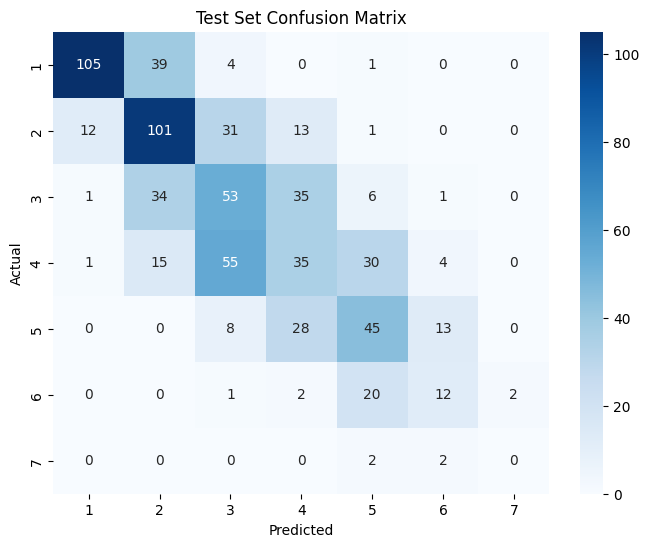


📊 Performance Comparison:
CV MAE: 0.674 | Test MAE: 0.657
Difference: 0.016
✅ Excellent generalization - CV and test results are very close!


In [11]:
# %% 10 Final evaluation on held-out test set
print("="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)

# Create test loader
test_loader = DataLoader(
    ShapeDataset(df_test, val_tf),  # Use val_tf (no augmentation)
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Evaluate best model on test set
best_model.eval()
test_preds, test_targs = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        test_preds.append(best_model(x).cpu())
        test_targs.append(y.cpu())

test_preds = torch.cat(test_preds)
test_targs = torch.cat(test_targs)

# Calculate metrics
test_mae = mae(test_preds, test_targs)
test_acc = acc_std(test_preds, test_targs)
test_tol = acc_tol(test_preds, test_targs)

print(f"Test MAE: {test_mae:.3f}")
print(f"Test Acc (±0): {test_acc:.1f}%")
print(f"Test Acc (±{TOL}): {test_tol:.1f}%")

# Plot test set confusion matrix
plt.figure(figsize=(8, 6))
pred_rounded = test_preds.numpy().round().clip(1,7).astype(int)
true_labels = test_targs.numpy().round().astype(int)
cm = confusion_matrix(true_labels, pred_rounded, labels=[1,2,3,4,5,6,7])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(1,8), yticklabels=range(1,8))
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Compare CV vs Test performance
print(f"\n📊 Performance Comparison:")
print(f"CV MAE: {np.mean(mae_list):.3f} | Test MAE: {test_mae:.3f}")
print(f"Difference: {abs(test_mae - np.mean(mae_list)):.3f}")
if abs(test_mae - np.mean(mae_list)) < 0.05:
    print("✅ Excellent generalization - CV and test results are very close!")
elif abs(test_mae - np.mean(mae_list)) < 0.1:
    print("✅ Good generalization - minor difference between CV and test")
else:
    print("⚠️ Larger gap between CV and test - might indicate overfitting")

In [12]:
# %% 11. Grad-CAM utils
def grad_cam(model, x, tgt_layer):
    acts, grads = [], []
    def fwd(m, i, o): acts.append(o)
    def bwd(m, gi, go): grads.append(go[0])
    h1 = tgt_layer.register_forward_hook(fwd)
    h2 = tgt_layer.register_backward_hook(bwd)
    model.zero_grad()
    out = model(x)
    out.backward(torch.ones_like(out))
    a, g = acts[0].squeeze(0), grads[0].squeeze(0)
    w = g.mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * a).sum(0))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    h1.remove(); h2.remove()
    return cam.detach().cpu().numpy()

def show_heat(img_t, cam):
    img = img_t.squeeze().cpu().numpy()
    cam = cv2.resize(cam, img.shape[::-1])
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (0.5 * heat + np.stack([img * 255] * 3, 2)).astype(np.uint8)

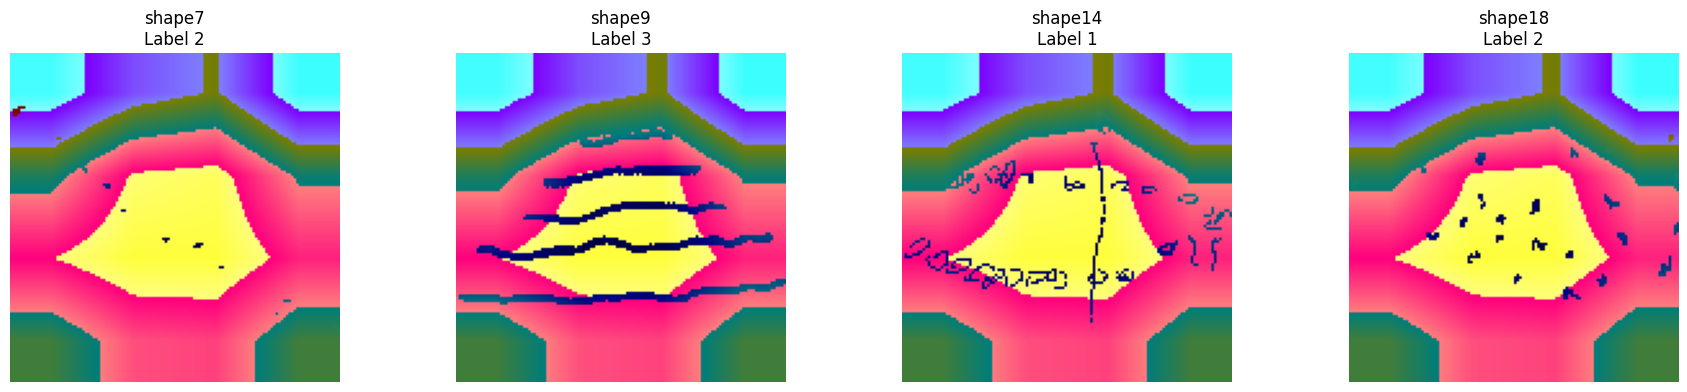

In [13]:
# %% 12. Grad-CAM demo – one example per shape group
tgt_layer = best_model.backbone.layer4

fig_idx = 1
plt.figure(figsize=(18, 4))

for shape_name in ["shape7", "shape9", "shape14", "shape18"]:
    # rows whose img_path contains this shape folder
    sub = df[df["img_path"].str.contains(f"/{shape_name}/")]
    if sub.empty:
        continue                       # skip if that shape wasn't in the merge
    row = sub.sample(1, random_state=SEED).iloc[0]

    # load + transform
    img_raw = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
    img_t   = val_tf(image=img_raw)["image"].float() / 255.0
    x       = img_t.unsqueeze(0).to(device)

    # Grad-CAM
    cam = grad_cam(best_model, x, tgt_layer)
    vis = show_heat(img_t, cam)

    # plot
    plt.subplot(1, 4, fig_idx)
    plt.imshow(vis); plt.axis("off")
    plt.title(f"{shape_name}\nLabel {int(row.label)}")
    fig_idx += 1

plt.tight_layout(); plt.show()


In [14]:
# %% Test single image with prediction and Grad-CAM

# ===== CHANGE THIS PATH TO YOUR IMAGE =====
test_image_path = "/content/10823.png"

# Load and preprocess the image
img_raw = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
if img_raw is None:
    print(f"Error: Could not load image from {test_image_path}")
else:
    # Apply the same preprocessing as validation
    img_transformed = val_tf(image=img_raw)["image"].float() / 255.0
    x = img_transformed.unsqueeze(0).to(device)

    # Get prediction
    best_model.eval()
    with torch.no_grad():
        prediction = best_model(x).cpu().item()

    rounded_pred = round(prediction)

    print("="*50)
    print(f"📍 Image: {test_image_path.split('/')[-1]}")
    print(f"📊 Raw prediction: {prediction:.3f}")
    print(f"🎯 Rounded score: {rounded_pred}")
    print("="*50)

    # Generate Grad-CAM
    tgt_layer = best_model.backbone.layer4
    cam = grad_cam(best_model, x, tgt_layer)
    heatmap_vis = show_heat(img_transformed, cam)

    # Visualize everything
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # 1. Original image
    axes[0].imshow(img_raw, cmap='gray')
    axes[0].set_title(f"Original Image\nShape: {img_raw.shape}")
    axes[0].axis('off')

    # 2. After smart crop & resize
    axes[1].imshow(img_transformed.squeeze().cpu().numpy(), cmap='gray')
    axes[1].set_title(f"After Preprocessing\n({IMG_SIZE}x{IMG_SIZE})")
    axes[1].axis('off')

    # 3. Grad-CAM heatmap
    axes[2].imshow(heatmap_vis)
    axes[2].set_title(f"Grad-CAM Heatmap\nFocus areas")
    axes[2].axis('off')

    # 4. Prediction bar chart
    scores = list(range(1, 8))
    bars = axes[3].bar(scores, [0]*7, color='lightgray')
    bars[rounded_pred-1].set_color('green')
    bars[rounded_pred-1].set_height(1)

    # Show raw prediction as a red line
    axes[3].axvline(x=prediction, color='red', linestyle='--', linewidth=2, label=f'Raw: {prediction:.2f}')
    axes[3].set_ylim(0, 1.2)
    axes[3].set_xlabel('Score')
    axes[3].set_title(f'Prediction: {prediction:.2f} → {rounded_pred}')
    axes[3].set_xticks(scores)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    # Interpretation
    print("\n💡 Interpretation:")
    if cam.max() > 0.7:
        print("• Strong activation areas detected - model is confident about specific features")
    else:
        print("• Diffuse activation - model is using broader image features")

    if abs(prediction - rounded_pred) < 0.2:
        print(f"• High confidence: prediction {prediction:.2f} is close to {rounded_pred}")
    else:
        print(f"• Borderline case: prediction {prediction:.2f} is between {int(prediction)} and {int(prediction)+1}")

# ===== Test multiple images at once (optional) =====
# Uncomment and modify paths to test multiple images
"""
test_images = [
    "/content/drive/MyDrive/test1.png",
    "/content/drive/MyDrive/test2.png",
    "/content/drive/MyDrive/test3.png"
]

for img_path in test_images:
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_t = val_tf(image=img)["image"].float() / 255.0
        x = img_t.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = best_model(x).cpu().item()

        print(f"{img_path.split('/')[-1]}: {pred:.3f} → {round(pred)}")
"""

Error: Could not load image from /content/10823.png


'\ntest_images = [\n    "/content/drive/MyDrive/test1.png",\n    "/content/drive/MyDrive/test2.png",\n    "/content/drive/MyDrive/test3.png"\n]\n\nfor img_path in test_images:\n    if os.path.exists(img_path):\n        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)\n        img_t = val_tf(image=img)["image"].float() / 255.0\n        x = img_t.unsqueeze(0).to(device)\n\n        with torch.no_grad():\n            pred = best_model(x).cpu().item()\n\n        print(f"{img_path.split(\'/\')[-1]}: {pred:.3f} → {round(pred)}")\n'

In [16]:
# %% Generate HTML files per shape (images sorted by predicted score) using in-memory best_model
import os, base64, cv2, numpy as np, torch
from datetime import datetime

assert 'best_model' in globals(), "best_model not found. Run training so best_model exists in memory."
assert 'val_tf' in globals(), "val_tf not found. Ensure your preprocessing (val_tf) is defined."
assert 'device' in globals(), "device not found. Ensure your notebook defined `device` (cpu/cuda)."
assert 'SHAPE_SOURCES' in globals(), "SHAPE_SOURCES not found."
assert 'df' in globals(), "df (merged labels) not found. Run the merging cell before this."

best_model.eval()

# Normalize SHAPE_SOURCES to {shape_name: folder_path}
shape_to_dir = {}
for k, v in SHAPE_SOURCES.items():
    if isinstance(v, (list, tuple)) and len(v) >= 2:
        shape_to_dir[k] = v[1]  # (score_file, img_dir)
    else:
        shape_to_dir[k] = v     # already a folder path

def predict_score(img_path: str) -> float:
    """Predict using the SAME preprocessing as validation (incl. Normalize).
       NOTE: no '/255.0' here—val_tf already normalizes."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return float("nan")
    t = val_tf(image=img)["image"].float()  # no extra scaling!
    t = t.unsqueeze(0).to(device)
    with torch.no_grad():
        return best_model(t).detach().cpu().item()

def img_to_data_uri(img_path: str) -> str:
    with open(img_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    ext = os.path.splitext(img_path)[1].lower()
    mime = "image/png" if ext == ".png" else ("image/jpeg" if ext in (".jpg", ".jpeg") else "image/png")
    return f"data:{mime};base64,{b64}"

def labels_for_shape(shape_name: str):
    """Map child_id -> label for this shape using your merged df."""
    sub = df[df["img_path"].str.contains(f"/{shape_name}/")]
    return {str(cid): int(lbl) for cid, lbl in zip(sub["child_id"].astype(str), sub["label"].astype(int))}

def make_html_for_shape(shape_name: str, folder: str):
    exts = {".png", ".jpg", ".jpeg", ".webp"}
    files = [f for f in os.listdir(folder) if os.path.splitext(f)[1].lower() in exts]
    files = [f for f in files if not f.lower().startswith("original")]  # skip reference

    # child_id -> true label (from df)
    lbl_map = labels_for_shape(shape_name)

    items = []
    for f in files:
        p = os.path.join(folder, f)
        child_id = os.path.splitext(f)[0]
        raw = predict_score(p)
        if np.isnan(raw):
            continue
        rnd = int(np.clip(np.rint(raw), 1, 7))
        true_lbl = lbl_map.get(child_id, None)
        abs_err = None if true_lbl is None else abs(rnd - int(true_lbl))
        items.append({
            "child_id": child_id,
            "raw": float(raw),
            "rnd": rnd,
            "true": (None if true_lbl is None else int(true_lbl)),
            "abs_err": (None if abs_err is None else int(abs_err)),
            "uri": img_to_data_uri(p)
        })

    # Sort by predicted score ascending
    items.sort(key=lambda x: x["raw"])

    ts = datetime.now().strftime("%Y-%m-%d %H:%M")
    html = [
        "<!doctype html><html><head><meta charset='utf-8'>",
        f"<title>{shape_name} predictions</title>",
        "<style>",
        "body{font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial,sans-serif;margin:20px}",
        ".controls{margin:6px 0 14px 0;display:flex;gap:10px;align-items:center}",
        ".grid{display:grid;grid-template-columns:repeat(5,1fr);gap:12px}",
        ".card{border:1px solid #ddd;border-radius:12px;padding:10px;box-shadow:0 1px 3px rgba(0,0,0,.06)}",
        ".card.bad{border-color:#e57373}",
        ".img{display:flex;justify-content:center;align-items:center}",
        "img{max-width:100%;height:auto;border-radius:8px;background:#000}",
        ".meta{margin-top:8px;font-size:14px;line-height:1.3}",
        ".meta b{font-weight:600}",
        ".tag{display:inline-block;padding:2px 6px;border-radius:6px;font-size:12px;margin-left:6px;background:#eee}",
        ".bad .tag{background:#fde0e0}",
        "@media(max-width:1100px){.grid{grid-template-columns:repeat(4,1fr)}}",
        "@media(max-width:900px){.grid{grid-template-columns:repeat(3,1fr)}}",
        "@media(max-width:700px){.grid{grid-template-columns:repeat(2,1fr)}}",
        "@media(max-width:480px){.grid{grid-template-columns:1fr}}",
        "</style></head><body>",
        f"<h2>{shape_name} — predicted scores (ascending)</h2>",
        f"<div style='color:#666;font-size:13px'>Generated {ts} • Total {len(items)}</div>",
        "<div class='controls'>",
        "<button id='toggle'>Show only errors &gt; ±1</button>",
        "<span style='color:#666;font-size:13px'>Error computed on <b>rounded</b> predictions.</span>",
        "</div>",
        "<div class='grid' id='grid'>"
    ]

    for it in items:
        label_txt = "N/A" if it["true"] is None else str(it["true"])
        err_txt   = "N/A" if it["abs_err"] is None else f"{it['abs_err']}"
        bad_cls   = " bad" if (it["abs_err"] is not None and it["abs_err"] > 1) else ""
        html += [
            f"<div class='card{bad_cls}' data-pred='{it['raw']:.4f}' "
            f"data-predr='{it['rnd']}' data-label='{label_txt}' data-abserr='{err_txt}'>",
            f"  <div class='img'><img src='{it['uri']}' alt='{it['child_id']}'></div>",
            "  <div class='meta'>",
            f"    child_id: <b>{it['child_id']}</b><br>",
            f"    pred: <b>{it['rnd']}</b> <span class='tag'>raw {it['raw']:.2f}</span><br>",
            f"    label: <b>{label_txt}</b>",
            f"    <span class='tag'>|Δ|: {err_txt}</span>",
            "  </div>",
            "</div>"
        ]
    html += [
        "</div>",
        "<script>",
        "const btn=document.getElementById('toggle');",
        "let showBad=false;",
        "btn.addEventListener('click',()=>{",
        "  showBad=!showBad;",
        "  btn.textContent=showBad?'Show all':'Show only errors > ±1';",
        "  document.querySelectorAll('.card').forEach(c=>{",
        "    const err=parseInt(c.dataset.abserr);",
        "    const isBad=!isNaN(err) && err>1;",
        "    c.style.display=(showBad? (isBad?'':'none') : '');",
        "  });",
        "});",
        "</script>",
        "</body></html>"
    ]

    out = f"/content/{shape_name}.html"
    with open(out, "w", encoding="utf-8") as f:
        f.write("\n".join(html))
    print(f"✅ Wrote {out} ({len(items)} images)")

# Run for all shapes
for shape, folder in shape_to_dir.items():
    if os.path.isdir(folder):
        make_html_for_shape(shape, folder)
    else:
        print(f"⚠️ Skipping {shape}: folder not found -> {folder}")

print("Done. Files saved to /content/:", ", ".join([f"{s}.html" for s in shape_to_dir.keys()]))


✅ Wrote /content/shape7.html (893 images)
✅ Wrote /content/shape9.html (898 images)
✅ Wrote /content/shape14.html (890 images)
✅ Wrote /content/shape18.html (876 images)
Done. Files saved to /content/: shape7.html, shape9.html, shape14.html, shape18.html


In [17]:
# %% Save best model (normalized + L2 setup)
save_path = "/content/best_resnet_reg_norm_l2.pth"
torch.save(best_model.state_dict(), save_path)
print(f"✅ Model saved to {save_path}")


✅ Model saved to /content/best_resnet_reg_norm_l2.pth
